# Projekt końcowy — klasyfikacja ryzyka niespłacenia karty kredytowej

**Cel biznesowy:** przewidzieć, czy klient nie spłaci zobowiązania w następnym miesiącu (`default = 1`). Na tej podstawie bank może podjąć decyzję, czy przyznać kartę kredytową.

W projekcie przechodzimy przez etapy: zrozumienie problemu, kontrola jakości danych, analiza eksploracyjna, przygotowanie cech, podział danych, model bazowy, strojenie modeli, dobór progu decyzji, ocena na zbiorze testowym, interpretacja i zapis modelu.

## 1. Import bibliotek i ustawienia

In [1]:
from pathlib import Path  # Ułatwia pracę ze ścieżkami do plików.
import warnings  # Pozwala ograniczyć mało istotne ostrzeżenia.
import json  # Umożliwia zapis metadanych modelu.

import joblib  # Służy do serializacji wytrenowanego modelu.
import numpy as np  # Udostępnia obliczenia numeryczne.
import pandas as pd  # Udostępnia struktury i narzędzia do analizy danych.
import matplotlib.pyplot as plt  # Służy do tworzenia wykresów.
import seaborn as sns  # Ułatwia tworzenie wykresów statystycznych.

from sklearn.base import clone  # Tworzy niezależną kopię estymatora.
from sklearn.dummy import DummyClassifier  # Tworzy prosty model bazowy.
from sklearn.tree import DecisionTreeClassifier  # Importuje klasyfikacyjne drzewo decyzyjne.
from sklearn.ensemble import RandomForestClassifier  # Importuje klasyfikacyjny las losowy.
from sklearn.linear_model import LogisticRegression  # Importuje regresję logistyczną.
from sklearn.pipeline import Pipeline  # Łączy skalowanie i model w jeden obiekt.
from sklearn.preprocessing import StandardScaler  # Standaryzuje cechy dla regresji logistycznej.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold  # Importuje podział i strojenie modeli.
from sklearn.metrics import (  # Importuje miary jakości klasyfikacji.
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 2022  # Ustala ziarno losowości dla powtarzalnych wyników.
TARGET = 'default payment next month'  # Określa nazwę zmiennej docelowej.
warnings.filterwarnings('ignore')  # Ukrywa ostrzeżenia, które nie wpływają na wynik projektu.
sns.set_theme(style='whitegrid')  # Ustawia czytelny styl wykresów.
pd.set_option('display.max_columns', 40)  # Pozwala wyświetlać wszystkie kolumny danych.

## 2. Wczytanie danych

Oryginalny plik `.xls` ma dwa wiersze nagłówkowe, dlatego stosujemy `header=1`. Notebook najpierw szuka pliku obok siebie i w katalogu kursu. Jeśli środowisko nie ma pakietu `xlrd`, używa dołączonej kopii CSV zawierającej te same dane.

In [2]:
notebook_dir = Path.cwd()  # Przyjmuje bieżący katalog jako katalog notebooka.
xls_candidates = [  # Definiuje możliwe lokalizacje oryginalnego pliku XLS.
    notebook_dir / 'default_of_credit_card_clients.xls',
    Path(r'C:\Users\micha\Desktop\Kodilla_Kurs\Modul20\default_of_credit_card_clients.xls')
]
csv_path = notebook_dir / 'default_of_credit_card_clients.csv'  # Definiuje ścieżkę do kopii CSV.

xls_path = next((path for path in xls_candidates if path.exists()), None)  # Wybiera pierwszą istniejącą ścieżkę XLS.

try:
    if xls_path is None:  # Sprawdza, czy znaleziono oryginalny plik.
        raise FileNotFoundError('Nie znaleziono pliku XLS.')
    dataframe_raw = pd.read_excel(xls_path, header=1)  # Wczytuje XLS z właściwym wierszem nagłówka.
    data_source = str(xls_path)  # Zapamiętuje wykorzystane źródło.
except (ImportError, ModuleNotFoundError, FileNotFoundError):
    dataframe_raw = pd.read_csv(csv_path)  # Wczytuje kopię CSV, jeśli XLS nie może zostać odczytany.
    dataframe_raw = dataframe_raw.iloc[2:].copy()  # Usuwa dwa techniczne wiersze nagłówkowe.
    dataframe_raw.columns = pd.read_csv(csv_path, nrows=2).iloc[1].tolist()  # Ustawia właściwe nazwy kolumn.
    dataframe_raw = dataframe_raw.apply(pd.to_numeric)  # Konwertuje wartości na typy liczbowe.
    data_source = str(csv_path)  # Zapamiętuje wykorzystane źródło.

print('Źródło:', data_source)  # Wyświetla wykorzystany plik.
print('Wymiary danych:', dataframe_raw.shape)  # Wyświetla liczbę wierszy i kolumn.
display(dataframe_raw.head())  # Pokazuje pierwsze obserwacje.

Źródło: C:\Users\micha\Desktop\Kodilla_Kurs\Modul20\default_of_credit_card_clients.csv
Wymiary danych: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
2,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
3,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
4,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
5,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
6,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Zrozumienie i kontrola jakości danych

In [3]:
dataframe_raw.info()  # Wyświetla typy danych i liczbę niepustych wartości.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 2 to 30001
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
quality_report = pd.DataFrame({  # Buduje raport jakości dla każdej kolumny.
    'dtype': dataframe_raw.dtypes.astype(str),
    'missing_count': dataframe_raw.isna().sum(),
    'missing_percent': dataframe_raw.isna().mean().mul(100).round(2),
    'unique_count': dataframe_raw.nunique()
})
display(quality_report)  # Wyświetla raport jakości danych.

print('Duplikaty identyfikatora:', dataframe_raw['ID'].duplicated().sum())  # Sprawdza powtórzone ID.
print('Pełne duplikaty bez ID:', dataframe_raw.drop(columns='ID').duplicated().sum())  # Sprawdza identyczne profile.

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.0,30000
LIMIT_BAL,int64,0,0.0,81
SEX,int64,0,0.0,2
EDUCATION,int64,0,0.0,7
MARRIAGE,int64,0,0.0,4
AGE,int64,0,0.0,56
PAY_0,int64,0,0.0,11
PAY_2,int64,0,0.0,11
PAY_3,int64,0,0.0,11
PAY_4,int64,0,0.0,11


Duplikaty identyfikatora: 0
Pełne duplikaty bez ID: 35


In [5]:
print('SEX:', sorted(dataframe_raw['SEX'].unique()))  # Sprawdza kody płci.
print('EDUCATION:', sorted(dataframe_raw['EDUCATION'].unique()))  # Sprawdza kody wykształcenia.
print('MARRIAGE:', sorted(dataframe_raw['MARRIAGE'].unique()))  # Sprawdza kody stanu cywilnego.
print('AGE:', dataframe_raw['AGE'].min(), '–', dataframe_raw['AGE'].max())  # Sprawdza zakres wieku.
print('LIMIT_BAL:', dataframe_raw['LIMIT_BAL'].min(), '–', dataframe_raw['LIMIT_BAL'].max())  # Sprawdza zakres limitu.

pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']  # Wskazuje kolumny historii spłat.
for column in pay_columns:  # Przechodzi przez wszystkie miesiące historii spłat.
    print(column, sorted(dataframe_raw[column].unique()))  # Wyświetla zaobserwowane statusy.

SEX: [np.int64(1), np.int64(2)]
EDUCATION: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
MARRIAGE: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
AGE: 21 – 79
LIMIT_BAL: 10000 – 1000000
PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64

### Wnioski z kontroli jakości

- Brak klasycznych wartości `NaN` i brak powtórzonych identyfikatorów.
- W `EDUCATION` występują nieopisane kody `0`, `5` i `6`; łączymy je z kategorią `4 = inne`.
- W `MARRIAGE` występuje nieopisany kod `0`; łączymy go z kategorią `3 = inne`.
- Statusy spłat zawierają `-2` i `0`, których skrócony opis zadania nie wyjaśnia. Nie usuwamy ich: są częścią oryginalnego kodowania zbioru i niosą informację o braku wykorzystania kredytu lub kredycie odnawialnym.
- Występuje 35 identycznych profili po pominięciu `ID`. Nie usuwamy ich automatycznie, ponieważ mogą reprezentować różnych klientów z tymi samymi wartościami zaokrąglonymi do pełnych dolarów tajwańskich.
- `ID` jest wyłącznie identyfikatorem i zostanie usunięte z modelu.

In [6]:
dataframe = dataframe_raw.copy()  # Tworzy kopię danych przed czyszczeniem.
dataframe['EDUCATION'] = dataframe['EDUCATION'].replace({0: 4, 5: 4, 6: 4})  # Łączy nieopisane poziomy wykształcenia z kategorią „inne”.
dataframe['MARRIAGE'] = dataframe['MARRIAGE'].replace({0: 3})  # Łączy nieopisany stan cywilny z kategorią „inne”.

assert dataframe[TARGET].isin([0, 1]).all()  # Potwierdza binarny charakter zmiennej docelowej.
assert dataframe['ID'].is_unique  # Potwierdza unikalność identyfikatora.
assert dataframe.isna().sum().sum() == 0  # Potwierdza brak pustych wartości.

## 4. Analiza zmiennej docelowej

,liczba,procent
spłata (0),23364,77.88
brak spłaty (1),6636,22.12


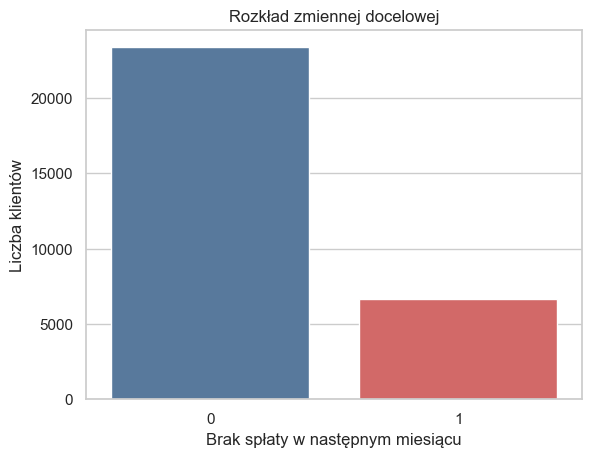

In [7]:
target_counts = dataframe[TARGET].value_counts().sort_index()  # Liczy obserwacje obu klas.
target_percent = dataframe[TARGET].value_counts(normalize=True).sort_index().mul(100)  # Oblicza udziały procentowe.
target_summary = pd.DataFrame({'liczba': target_counts, 'procent': target_percent.round(2)})  # Łączy wyniki.
target_summary.index = ['spłata (0)', 'brak spłaty (1)']  # Nadaje czytelne etykiety.
display(target_summary)  # Wyświetla rozkład klas.

ax = sns.countplot(data=dataframe, x=TARGET, palette=['#4C78A8', '#E45756'])  # Rysuje liczebność klas.
ax.set(title='Rozkład zmiennej docelowej', xlabel='Brak spłaty w następnym miesiącu', ylabel='Liczba klientów')  # Opisuje wykres.
plt.show()  # Wyświetla wykres.

Klasa `1` stanowi około 22% danych. Samo accuracy byłoby mylące: model przewidujący zawsze spłatę osiągnie około 78% accuracy, ale nie wykryje żadnego ryzykownego klienta. Dlatego główne miary to **recall klasy 1**, **F2** (silniej premiuje recall) oraz **PR-AUC**. ROC-AUC i balanced accuracy są miarami uzupełniającymi.

## 5. Analiza eksploracyjna

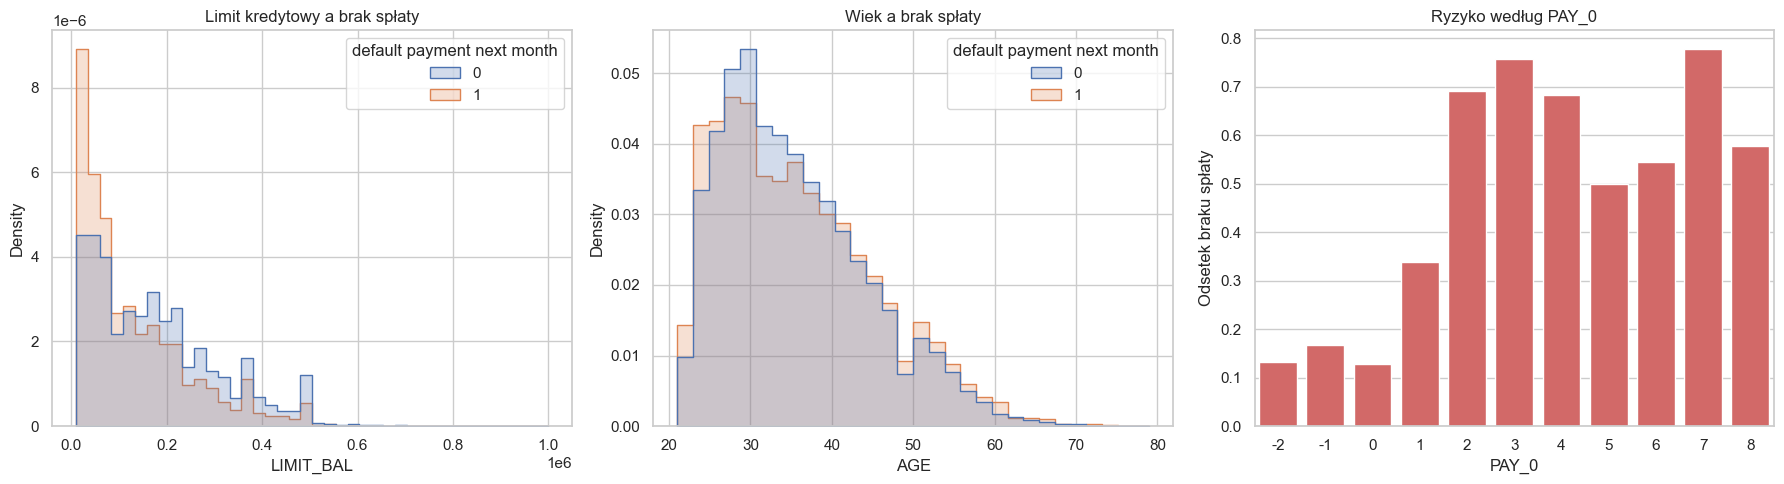

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Tworzy trzy wykresy obok siebie.
sns.histplot(data=dataframe, x='LIMIT_BAL', hue=TARGET, bins=40, element='step', stat='density', common_norm=False, ax=axes[0])  # Pokazuje rozkład limitu.
axes[0].set_title('Limit kredytowy a brak spłaty')  # Nadaje tytuł pierwszemu wykresowi.
sns.histplot(data=dataframe, x='AGE', hue=TARGET, bins=30, element='step', stat='density', common_norm=False, ax=axes[1])  # Pokazuje rozkład wieku.
axes[1].set_title('Wiek a brak spłaty')  # Nadaje tytuł drugiemu wykresowi.
default_by_pay0 = dataframe.groupby('PAY_0')[TARGET].mean().reset_index()  # Oblicza udział braku spłaty według statusu wrześniowego.
sns.barplot(data=default_by_pay0, x='PAY_0', y=TARGET, color='#E45756', ax=axes[2])  # Rysuje ryzyko według statusu spłaty.
axes[2].set(title='Ryzyko według PAY_0', ylabel='Odsetek braku spłaty')  # Opisuje trzeci wykres.
plt.tight_layout()  # Dopasowuje odstępy.
plt.show()  # Wyświetla wykresy.

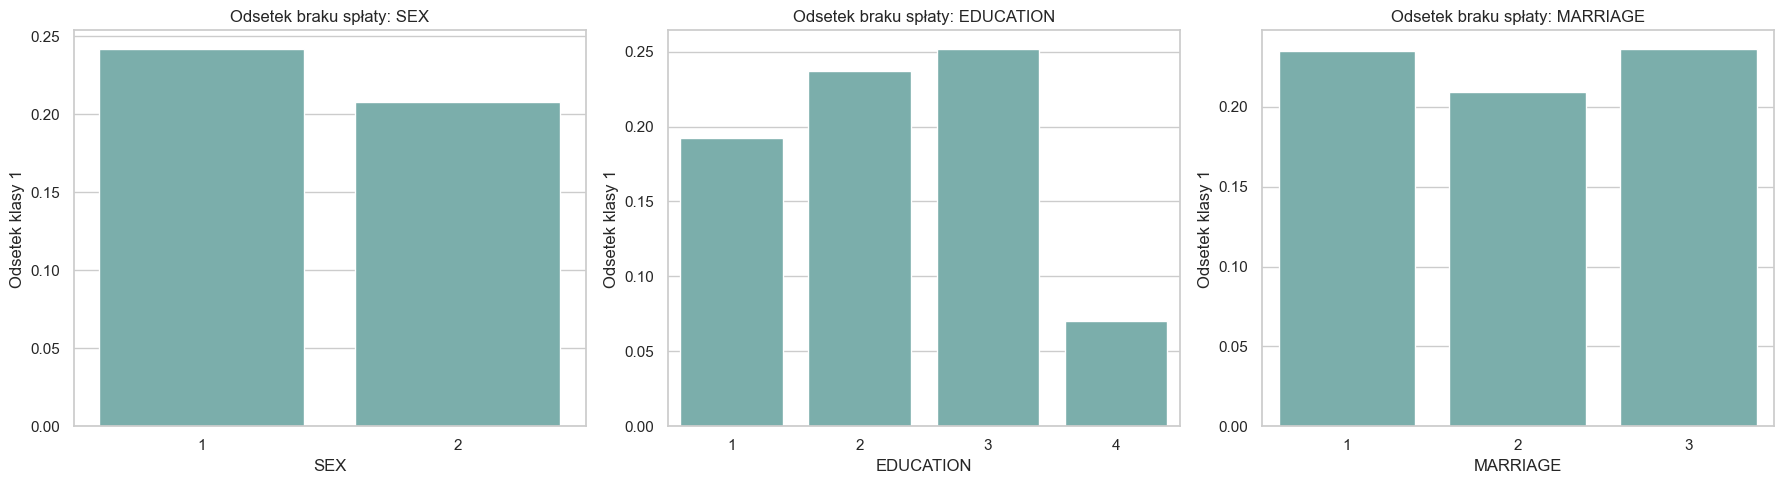

In [9]:
categorical_columns = ['SEX', 'EDUCATION', 'MARRIAGE']  # Wskazuje podstawowe cechy kategoryczne.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Tworzy miejsce na trzy wykresy.
for column, axis in zip(categorical_columns, axes):  # Łączy kolumnę z osią wykresu.
    rates = dataframe.groupby(column)[TARGET].mean().reset_index()  # Oblicza odsetek braku spłaty w kategorii.
    sns.barplot(data=rates, x=column, y=TARGET, color='#72B7B2', ax=axis)  # Rysuje odsetek braku spłaty.
    axis.set(title=f'Odsetek braku spłaty: {column}', ylabel='Odsetek klasy 1')  # Nadaje opisy.
plt.tight_layout()  # Dopasowuje odstępy.
plt.show()  # Wyświetla wykresy.

## 6. Inżynieria cech

In [10]:
bill_columns = [f'BILL_AMT{i}' for i in range(1, 7)]  # Wskazuje sześć kwot rachunków.
payment_columns = [f'PAY_AMT{i}' for i in range(1, 7)]  # Wskazuje sześć kwot wcześniejszych spłat.

dataframe['BILL_MEAN_6M'] = dataframe[bill_columns].mean(axis=1)  # Oblicza średni rachunek z sześciu miesięcy.
dataframe['PAYMENT_MEAN_6M'] = dataframe[payment_columns].mean(axis=1)  # Oblicza średnią spłatę z sześciu miesięcy.
dataframe['UTILIZATION_MEAN'] = dataframe['BILL_MEAN_6M'] / dataframe['LIMIT_BAL'].clip(lower=1)  # Oblicza średnie wykorzystanie limitu.
dataframe['PAYMENT_TO_BILL'] = dataframe[payment_columns].sum(axis=1) / dataframe[bill_columns].clip(lower=0).sum(axis=1).clip(lower=1)  # Porównuje spłaty z dodatnimi rachunkami.
dataframe['DELAY_MONTHS_COUNT'] = (dataframe[pay_columns] > 0).sum(axis=1)  # Liczy miesiące z opóźnieniem.
dataframe['MAX_DELAY'] = dataframe[pay_columns].max(axis=1)  # Wyznacza największe opóźnienie.
dataframe['RECENT_BILL_CHANGE'] = dataframe['BILL_AMT1'] - dataframe['BILL_AMT6']  # Mierzy zmianę rachunku między kwietniem a wrześniem.
dataframe['RECENT_PAYMENT_CHANGE'] = dataframe['PAY_AMT1'] - dataframe['PAY_AMT6']  # Mierzy zmianę spłaty między kwietniem a wrześniem.

dataframe.replace([np.inf, -np.inf], np.nan, inplace=True)  # Zamienia nieskończoności na braki.
dataframe.fillna(0, inplace=True)  # Uzupełnia ewentualne braki powstałe przy dzieleniu.

## 7. Podział na zbiory treningowy, walidacyjny i testowy

In [11]:
X = dataframe.drop(columns=[TARGET, 'ID'])  # Tworzy zbiór cech bez celu i identyfikatora.
y = dataframe[TARGET].astype(int)  # Tworzy binarną zmienną docelową.

X_train_val, X_test, y_train_val, y_test = train_test_split(  # Oddziela nietykany zbiór testowy.
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_valid, y_train, y_valid = train_test_split(  # Oddziela zbiór walidacyjny do wyboru progu.
    X_train_val, y_train_val, test_size=0.20, stratify=y_train_val, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({  # Podsumowuje wielkość i udział klasy pozytywnej.
    'zbiór': ['train', 'validation', 'test'],
    'liczba': [len(y_train), len(y_valid), len(y_test)],
    'udział_default': [y_train.mean(), y_valid.mean(), y_test.mean()]
})
display(split_summary)  # Wyświetla kontrolę podziału.

,zbiór,liczba,udział_default
0,train,19200,0.221198
1,validation,4800,0.221250
2,test,6000,0.221167


## 8. Funkcje oceny

In [12]:
def calculate_metrics(y_true, probability, threshold=0.5):  # Definiuje zestaw miar klasyfikacji.
    prediction = (np.asarray(probability) >= threshold).astype(int)  # Zamienia prawdopodobieństwa na klasy.
    return {  # Zwraca najważniejsze miary.
        'accuracy': accuracy_score(y_true, prediction),
        'balanced_accuracy': balanced_accuracy_score(y_true, prediction),
        'precision': precision_score(y_true, prediction, zero_division=0),
        'recall': recall_score(y_true, prediction, zero_division=0),
        'f1': f1_score(y_true, prediction, zero_division=0),
        'f2': fbeta_score(y_true, prediction, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_true, probability),
        'pr_auc': average_precision_score(y_true, probability)
    }


def find_best_f2_threshold(y_true, probability):  # Szuka progu maksymalizującego F2 na walidacji.
    thresholds = np.linspace(0.10, 0.90, 161)  # Tworzy progi od 0,10 do 0,90.
    scores = [fbeta_score(y_true, np.asarray(probability) >= threshold, beta=2) for threshold in thresholds]  # Liczy F2 dla każdego progu.
    best_position = int(np.argmax(scores))  # Znajduje pozycję najlepszego wyniku.
    return float(thresholds[best_position]), float(scores[best_position])  # Zwraca najlepszy próg i F2.

## 9. Model bazowy

In [13]:
baseline_model = DummyClassifier(strategy='prior')  # Tworzy model używający wyłącznie udziałów klas.
baseline_model.fit(X_train, y_train)  # Dopasowuje model bazowy.
baseline_probability = baseline_model.predict_proba(X_valid)[:, 1]  # Oblicza prawdopodobieństwo klasy 1.
baseline_metrics = calculate_metrics(y_valid, baseline_probability, threshold=0.5)  # Ocenia baseline na walidacji.
display(pd.DataFrame([baseline_metrics], index=['DummyClassifier']))  # Wyświetla wyniki modelu bazowego.

,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
DummyClassifier,0.77875,0.5,0.0,0.0,0.0,0.0,0.5,0.22125


## 10. Strojenie modeli

In [14]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)  # Tworzy warstwową walidację krzyżową.

models = {  # Definiuje modele i siatki parametrów.
    'LogisticRegression': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        {'model__C': [0.01, 0.1, 1.0, 10.0]}
    ),
    'DecisionTree': (
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
        {'max_depth': [3, 5, 8, 12], 'min_samples_leaf': [20, 50, 100]}
    ),
    'RandomForest': (
        RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1),
        {'max_depth': [6, 10, 14, None], 'min_samples_leaf': [5, 20]}
    )
}

searches = {}  # Przygotowuje miejsce na wyniki GridSearchCV.
validation_rows = []  # Przygotowuje listę wyników walidacyjnych.

for name, (estimator, param_grid) in models.items():  # Strojenie każdego modelu osobno.
    print(f'\nStrojenie: {name}')  # Informuje o aktualnym modelu.
    search = GridSearchCV(  # Tworzy wyszukiwanie hiperparametrów.
        estimator=estimator,
        param_grid=param_grid,
        scoring='average_precision',  # Optymalizuje PR-AUC odpowiednie dla niezbalansowanych klas.
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    search.fit(X_train, y_train)  # Dopasowuje wszystkie kombinacje na zbiorze treningowym.
    probability = search.best_estimator_.predict_proba(X_valid)[:, 1]  # Oblicza prognozy walidacyjne.
    threshold, validation_f2 = find_best_f2_threshold(y_valid, probability)  # Dobiera próg bez użycia testu.
    metrics = calculate_metrics(y_valid, probability, threshold)  # Oblicza miary dla wybranego progu.
    validation_rows.append({'model': name, 'threshold': threshold, **metrics})  # Zapisuje wyniki.
    searches[name] = search  # Zachowuje wytrenowany GridSearchCV.
    print('Najlepsze parametry:', search.best_params_)  # Wyświetla najlepsze parametry.

validation_results = pd.DataFrame(validation_rows).sort_values('f2', ascending=False)  # Porządkuje modele według F2.
display(validation_results.round(4))  # Wyświetla porównanie modeli.


Strojenie: LogisticRegression
Fitting 4 folds for each of 4 candidates, totalling 16 fits
Najlepsze parametry: {'model__C': 0.01}

Strojenie: DecisionTree
Fitting 4 folds for each of 12 candidates, totalling 48 fits
Najlepsze parametry: {'max_depth': 8, 'min_samples_leaf': 100}

Strojenie: RandomForest
Fitting 4 folds for each of 8 candidates, totalling 32 fits
Najlepsze parametry: {'max_depth': 10, 'min_samples_leaf': 5}


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
2,RandomForest,0.245,0.4938,0.6446,0.2935,0.9153,0.4444,0.6429,0.7864,0.5693
1,DecisionTree,0.285,0.5183,0.6456,0.2988,0.8738,0.4453,0.6309,0.7692,0.5395
0,LogisticRegression,0.360,0.6221,0.6751,0.3425,0.7702,0.4742,0.6163,0.7552,0.5025


## 11. Wybór modelu i ostateczna ocena

In [15]:
best_model_name = validation_results.iloc[0]['model']  # Wybiera model o najwyższym walidacyjnym F2.
best_threshold = float(validation_results.iloc[0]['threshold'])  # Zachowuje próg dobrany na walidacji.
best_parameters = searches[best_model_name].best_params_  # Pobiera najlepsze hiperparametry.

final_model = clone(searches[best_model_name].best_estimator_)  # Tworzy świeżą kopię najlepszego modelu.
final_model.fit(X_train_val, y_train_val)  # Trenuje go ponownie na danych treningowych i walidacyjnych.

test_probability = final_model.predict_proba(X_test)[:, 1]  # Oblicza prawdopodobieństwo braku spłaty na teście.
test_prediction = (test_probability >= best_threshold).astype(int)  # Stosuje próg wybrany na walidacji.
test_metrics = calculate_metrics(y_test, test_probability, best_threshold)  # Oblicza końcowe miary.

print('Wybrany model:', best_model_name)  # Wyświetla nazwę modelu.
print('Najlepsze parametry:', best_parameters)  # Wyświetla parametry modelu.
print('Próg decyzji:', round(best_threshold, 3))  # Wyświetla dobrany próg.
display(pd.DataFrame([test_metrics], index=['test']).round(4))  # Wyświetla końcowe wyniki.
print(classification_report(y_test, test_prediction, target_names=['spłata', 'brak spłaty']))  # Wyświetla raport klas.

Wybrany model: RandomForest
Najlepsze parametry: {'max_depth': 10, 'min_samples_leaf': 5}
Próg decyzji: 0.245


,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
test,0.4697,0.6288,0.2833,0.9141,0.4326,0.6325,0.7864,0.5604


              precision    recall  f1-score   support

      spłata       0.93      0.34      0.50      4673
 brak spłaty       0.28      0.91      0.43      1327

    accuracy                           0.47      6000
   macro avg       0.61      0.63      0.47      6000
weighted avg       0.79      0.47      0.49      6000



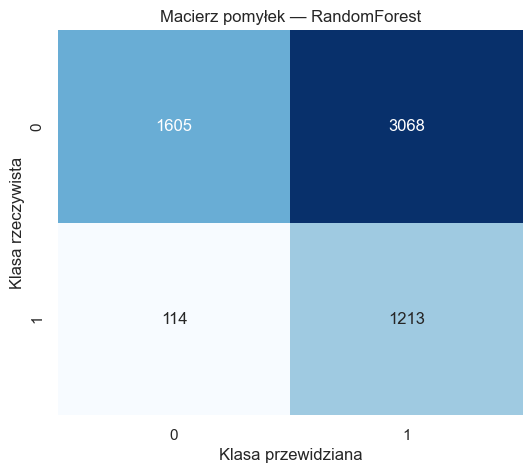

In [16]:
matrix = confusion_matrix(y_test, test_prediction)  # Oblicza macierz pomyłek.
plt.figure(figsize=(6, 5))  # Tworzy obszar wykresu.
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)  # Rysuje macierz pomyłek.
plt.xlabel('Klasa przewidziana')  # Opisuje oś poziomą.
plt.ylabel('Klasa rzeczywista')  # Opisuje oś pionową.
plt.title(f'Macierz pomyłek — {best_model_name}')  # Nadaje tytuł.
plt.show()  # Wyświetla wykres.

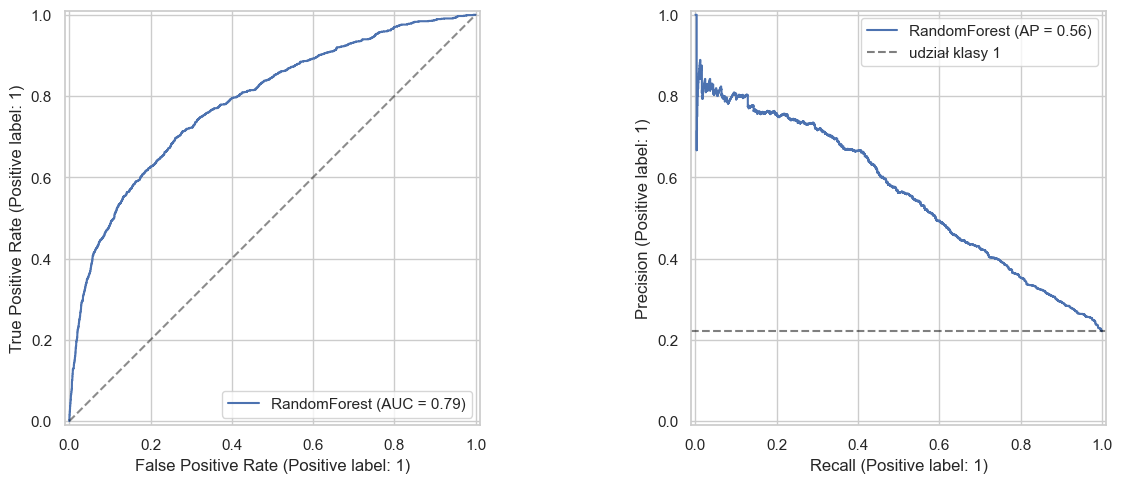

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))  # Tworzy miejsce na krzywe ROC i precision-recall.
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[0], name=best_model_name)  # Rysuje krzywą ROC.
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)  # Dodaje linię losowego klasyfikatora.
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[1], name=best_model_name)  # Rysuje krzywą precision-recall.
axes[1].axhline(y_test.mean(), color='black', linestyle='--', alpha=0.5, label='udział klasy 1')  # Dodaje poziom bazowy.
axes[1].legend()  # Wyświetla legendę.
plt.tight_layout()  # Dopasowuje odstępy.
plt.show()  # Wyświetla wykresy.

### Interpretacja biznesowa macierzy pomyłek

- **True negative:** klient spłacił i model rekomendował przyznanie karty.
- **False positive:** klient spłacił, ale model oznaczył go jako ryzykownego — możliwa utrata dobrego klienta.
- **False negative:** klient nie spłacił, ale model uznał go za bezpiecznego — zwykle najbardziej kosztowny błąd.
- **True positive:** klient nie spłacił i model prawidłowo wykrył ryzyko.

Obniżenie progu zwiększa wykrywalność ryzykownych klientów, lecz zwiększa również liczbę odrzuconych klientów, którzy faktycznie spłaciliby zobowiązanie. Ostateczny próg powinien wynikać z kosztów obu błędów, apetytu na ryzyko i wymogów regulacyjnych.

## 12. Interpretacja modelu

,feature,importance
5,PAY_0,0.132816
28,MAX_DELAY,0.131305
27,DELAY_MONTHS_COUNT,0.104778
6,PAY_2,0.056280
25,UTILIZATION_MEAN,0.037598
24,PAYMENT_MEAN_6M,0.034863
7,PAY_3,0.034419
26,PAYMENT_TO_BILL,0.031260
0,LIMIT_BAL,0.029805
11,BILL_AMT1,0.027749


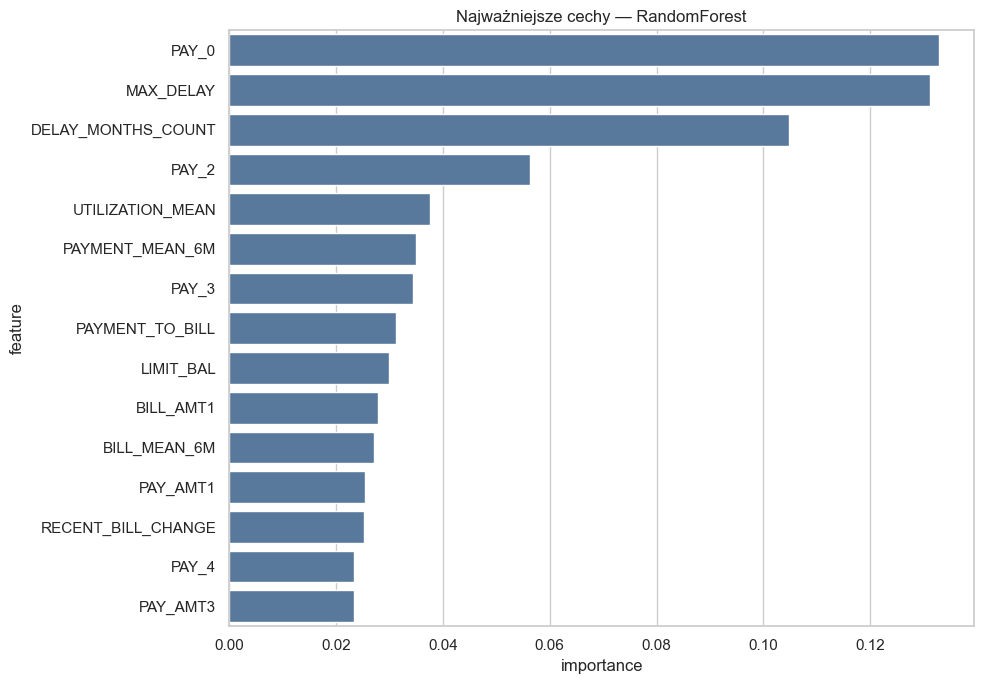

In [18]:
if hasattr(final_model, 'feature_importances_'):  # Sprawdza, czy model udostępnia ważności cech.
    importance_values = final_model.feature_importances_  # Pobiera ważności z modelu drzewiastego.
elif isinstance(final_model, Pipeline):  # Sprawdza, czy wybrano pipeline regresji logistycznej.
    importance_values = np.abs(final_model.named_steps['model'].coef_[0])  # Pobiera bezwzględne współczynniki.
else:
    importance_values = np.zeros(X_train_val.shape[1])  # Tworzy wartości zerowe jako zabezpieczenie.

importance = pd.DataFrame({  # Łączy cechy z ich ważnością.
    'feature': X_train_val.columns,
    'importance': importance_values
}).sort_values('importance', ascending=False).head(15)  # Wybiera 15 najważniejszych cech.

display(importance)  # Wyświetla ranking cech.
plt.figure(figsize=(10, 7))  # Tworzy obszar wykresu.
sns.barplot(data=importance, x='importance', y='feature', color='#4C78A8')  # Rysuje ważności cech.
plt.title(f'Najważniejsze cechy — {best_model_name}')  # Nadaje tytuł.
plt.tight_layout()  # Dopasowuje elementy.
plt.show()  # Wyświetla wykres.

Ważność cechy informuje, jak intensywnie model wykorzystuje ją do podejmowania decyzji, ale nie dowodzi związku przyczynowego. W modelach drzewiastych jest to globalna ważność oparta na poprawie podziałów; nie pokazuje bezpośrednio kierunku wpływu. Do szczegółowej analizy pojedynczych decyzji można dodatkowo użyć SHAP, pamiętając o osobnej instalacji biblioteki.

## 13. Reguła decyzji i zapis modelu

In [19]:
decision_example = pd.DataFrame({  # Tworzy przykładową tabelę decyzji dla pierwszych klientów testowych.
    'probability_of_default': test_probability[:10],
    'predicted_default': test_prediction[:10]
}, index=X_test.index[:10])
decision_example['card_decision'] = np.where(  # Zamienia prognozę ryzyka na prostą rekomendację.
    decision_example['predicted_default'].eq(1),
    'odmowa / dodatkowa weryfikacja',
    'można rozważyć przyznanie'
)
display(decision_example)  # Wyświetla przykładowe rekomendacje.

,probability_of_default,predicted_default,card_decision
12926,0.726696,1,odmowa / dodatkowa weryfikacja
29944,0.331582,1,odmowa / dodatkowa weryfikacja
25694,0.092333,0,można rozważyć przyznanie
7879,0.179085,0,można rozważyć przyznanie
17570,0.455065,1,odmowa / dodatkowa weryfikacja
6550,0.341110,1,odmowa / dodatkowa weryfikacja
17011,0.109337,0,można rozważyć przyznanie
20825,0.368003,1,odmowa / dodatkowa weryfikacja
27494,0.398059,1,odmowa / dodatkowa weryfikacja
11764,0.151678,0,można rozważyć przyznanie


In [20]:
model_package = {  # Buduje paczkę potrzebną do późniejszego użycia modelu.
    'model': final_model,
    'threshold': best_threshold,
    'feature_columns': list(X_train_val.columns),
    'target_name': TARGET,
    'education_mapping': {0: 4, 5: 4, 6: 4},
    'marriage_mapping': {0: 3},
    'selected_model': best_model_name,
    'best_parameters': best_parameters,
    'test_metrics': test_metrics
}

joblib.dump(model_package, 'credit_default_model.joblib')  # Zapisuje model, próg i metadane do pliku.
print('Zapisano: credit_default_model.joblib')  # Potwierdza zapis.

Zapisano: credit_default_model.joblib


## 14. Podsumowanie

Projekt:

1. zidentyfikował i naprawił nieudokumentowane kategorie danych,
2. usunął identyfikator z modelowania,
3. uwzględnił niezbalansowanie klas,
4. porównał model bazowy, regresję logistyczną, drzewo i las losowy,
5. dobrał hiperparametry wyłącznie na danych treningowych,
6. dobrał próg klasyfikacji na zbiorze walidacyjnym,
7. ocenił wybrany model tylko raz na nietykanym zbiorze testowym,
8. zapisał model razem z progiem i listą wymaganych cech.

Przed wdrożeniem należy jeszcze ustalić rzeczywisty koszt błędów, sprawdzić kalibrację prawdopodobieństw, przeprowadzić analizę fairness oraz monitorować zmianę rozkładu danych i jakości modelu w czasie.